In [1]:
import supervenn, pandas

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# define annotations for later

In [3]:
annotation_file = '/Users/adrian/research/016.saudarkrokur/results/deseq2/annotation.tsv'
annotation = pandas.read_csv(annotation_file, sep='\t')
annotation.drop(['Unnamed: 0', 'ensembl_transcript_id'], inplace=True, axis='columns')
annotation.drop_duplicates(subset='ensembl_gene_id', inplace=True)
annotation.set_index('ensembl_gene_id', inplace=True)
annotation

,external_gene_name,entrezgene_id,gene_biotype,description
ensembl_gene_id,,,,
FBgn0029843,Nep1,31547.0,protein_coding,Neprilysin 1
FBgn0266278,lncRNA:CR44963,19835737.0,ncRNA,long non-coding RNA:CR44963
FBgn0026238,gus,35478.0,protein_coding,gustavus
FBgn0035235,CG7879,38184.0,protein_coding,NaN
FBti0018960,flea{}771,NaN,transposable_element,NaN
...,...,...,...,...
FBgn0038358,Ttc26,41905.0,protein_coding,Tetratricopeptide repeat domain 26
FBtr0445469_df_nrg,NaN,NaN,ncRNA,NaN
FBgn0030989,Inx5,32901.0,protein_coding,Innexin 5


# super venn

In [4]:
input_dir = '/Users/adrian/research/016.saudarkrokur/results/deseq2/'

df = pandas.read_csv(input_dir+'effect_ko_wt.for.tsv', sep='\t', index_col=0)
a = set(df.index)
print(len(a))

df = pandas.read_csv(input_dir+'effect_h1M8_ko.for.tsv', sep='\t', index_col=0)
b = set(df.index)
print(len(b))

df = pandas.read_csv(input_dir+'effect_h1M8_wt.for.tsv', sep='\t', index_col=0)
c = set(df.index)
print(len(c))

1011
434
767


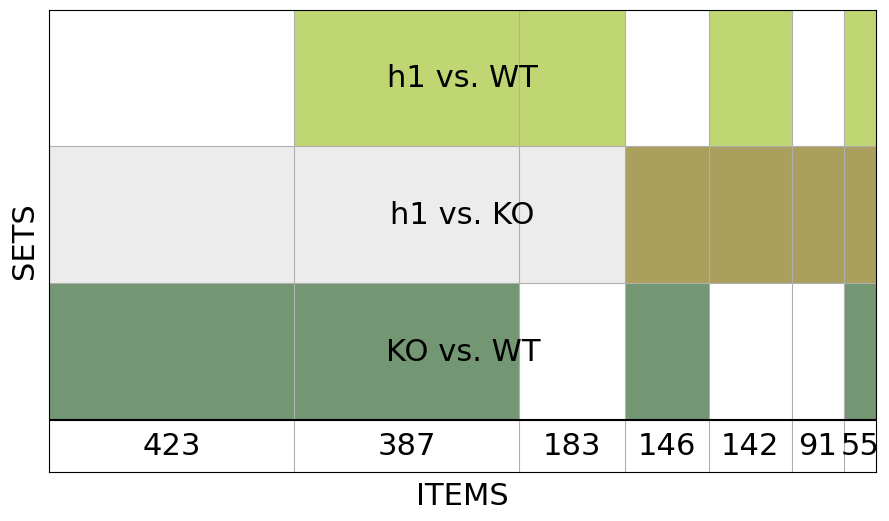

In [5]:
sets = [a, b, c]
labels = ['KO vs. WT', 'h1 vs. KO', 'h1 vs. WT']
mso = supervenn.supervenn(sets, labels,
                          side_plots=False, chunks_ordering='size', 
                          reverse_sets_order=False, fontsize=22, color_cycle=['#165016', '#806C00', '#96BC16']) 
# colors blended here: https://meyerweb.com/eric/tools/color-blend
# took the middle of a blend of resolution five

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('venn.svg')

In [6]:
a = mso.chunks[frozenset({0})]
b = mso.chunks[frozenset({1})]
c = mso.chunks[frozenset({2})]

d = mso.chunks[frozenset({1, 2})]
e = mso.chunks[frozenset({0, 1})]
f = mso.chunks[frozenset({0, 2})]

g = mso.chunks[frozenset({0, 1, 2})]

labels = [str(len(a)), str(len(b)), str(len(c)), str(len(d)), str(len(e)), str(len(f)), str(len(g))]
interesting_sets = [a, b, c, d, e, f, g]

for i in range(len(labels)):
    working_set = interesting_sets[i]
    path = '/Users/adrian/research/016.saudarkrokur/results/deseq2/h1_sets/' + labels[i] + '.tsv'
    annset = annotation[annotation.index.isin(working_set)]
    print(annset.shape)
    annset.to_csv(path, sep='\t')

(423, 4)
(91, 4)
(183, 4)
(142, 4)
(146, 4)
(387, 4)
(55, 4)
